# Build database of spatial footprints for input CSDA Program Evaluation Imagery

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | Innovation Lab ; NASA Goddard Space Flight Center | Nov. 2025 |

In [1]:
#pip install matplotlib_scalebar

In [1]:
import geopandas as gpd
import pandas as pd
from urllib.parse import quote
import numpy as np
import os, sys

sys.path.append('/home/pmontesa/code/geoscitools')

sys.path.append('/home/pmontesa/code/csda_summaries/lib')

In [2]:
import glob
import importlib
import re
import os
from pathlib import Path
from collections import Counter
import pandas as pd
import geopandas as gpd

import csdalib # changed from csdalib_refoactored

# If sensor_profiles.py is separate
import sensor_profiles
importlib.reload(sensor_profiles)

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3

<module 'sensor_profiles' from '/home/pmontesa/code/csda_summaries/lib/sensor_profiles.py'>

## CSDA Database

In [3]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'

### Requested Acquisitions

In [4]:
SHEET_NAME = 'Requested Acquisitions' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    requested_acqs = pd.read_csv(url)
    requested_acqs = requested_acqs.drop(columns=[col for col in requested_acqs.columns if 'Unnamed:' in col])
    requested_acqs['Site'] = requested_acqs['Site'].str.rstrip()
    
except Exception as e:
    print(f"An error occurred: {e}")

print(f"{len(requested_acqs)} rows; {requested_acqs['Acquisitions Requested'].sum()} requests in total")
requested_acqs.Site.unique()

77 rows; 336 requests in total


array(['La Crau', 'Piedmont', 'Gobabeb', 'Railroad Valley',
       'Salon-de-Provence', 'PICS Libya-4', 'PICS Algeria-3', 'London',
       'Boston', 'Shadnagar', 'Melbourne', 'WLEF', 'Valencia',
       'Suramadu Bridge', 'Navarre Causway', 'Albuquerque', 'Hothot',
       'Cuprite', 'Cape Town', 'King Fahd Causeway', 'Caspian Sea',
       'Crater Lake', 'Old Bahia Br', 'Baotou', 'Sapporo', 'Casablanca',
       'Belo Horizonte'], dtype=object)

### Check which sensor profiles are available for making footprints

In [5]:
from csdalib import SENSOR_PROFILES, detect_vendor

print('Loaded profiles:')
for k, v in SENSOR_PROFILES.items():
    print(f"  {k:15s} → {v['affiliation']} / {v.get('constellation', '<dynamic>')}")

Loaded profiles:
  tanager         → Planet / Tanager
  legion          → Maxar / Legion
  maxar_imd       → Maxar / <dynamic>
  maxar_legacy    → Maxar / <dynamic>
  pixxel_fpt      → Pixxel / Firefly
  pixxel          → Pixxel / Firefly
  airbus_dimap    → Airbus / <dynamic>
  satellogic      → Satellogic / Aleph-1


## Build list of files to footprint

In [6]:
# Get today's date as a pandas Timestamp object
today_timestamp = pd.Timestamp.today()

# Convert the Timestamp object to a string in a specific format (e.g., YYYY-MM-DD)
today_date_string = today_timestamp.strftime('%Y-%m-%d')

## Search

In [7]:
# ---- 1. Configure search ----
ROOT_DIR = '/explore/nobackup/projects/CSDA_eval/Data'
VENDOR_SUBDIRS = [
    'Satellogic',
    'Planet',
    'Pixxel', 
    'Maxar',
    'Airbus'
]

SEARCH_PATTERNS = ['*.TIF', '*.tif', '*.JP2', '*.jp2', '*.json', '*.geojson']

In [8]:
# ---- 2. Find candidate files per vendor subdir ----
all_files = []
for sub in VENDOR_SUBDIRS:
    for pat in SEARCH_PATTERNS:
        hits = glob.glob(f'{ROOT_DIR}/{sub}/**/{pat}', recursive=True)
        all_files.extend(hits)

print(f'Found {len(all_files)} candidate files across {len(VENDOR_SUBDIRS)} vendor subdirs')

Found 5468 candidate files across 5 vendor subdirs


In [9]:
# ---- 3. Skip noise files (ie preview and other files that shouldnt be footprinted) ----
SKIP_PATTERNS = [
    r'-request\.json$',
    r'_manifest\.json$',
    r'README',
    r'^CCS_', r'^CLD_', r'^DCL_', r'^HAZ_', r'^MSK_', r'^GFP_',
    r'_TCI\.tif$',   # ← Pixxel True Color Image preview (not primary data)
    r'_TCI\.jpeg$',
    r'_PCL\.tif$',   # ← Pixxel Product Classification Layer (also auxiliary)
]

def is_skip(path):
    fn = Path(path).name.lower()
    return any(re.search(p, fn, re.IGNORECASE) for p in SKIP_PATTERNS)

n_before = len(all_files)
all_files = [f for f in all_files if not is_skip(f)]
print(f'Filtered out {n_before - len(all_files)} noise files')
print(f'Remaining files to process: {len(all_files)}')

Filtered out 499 noise files
Remaining files to process: 4969


In [10]:
# ---- 4. Pre-filter: keep only files where dispatcher detects a vendor ----
detected = []
unmatched = []
for f in all_files:
    profile = csdalib.detect_vendor(f)
    if profile:
        detected.append((f, profile))
    else:
        unmatched.append(f)

print(f'Recognized: {len(detected)} files')
print(f'Unmatched:  {len(unmatched)} files')

print('\nFiles per detected profile:')
for p, n in Counter(p for _, p in detected).most_common():
    print(f'  {p:20s}: {n}')

Recognized: 4952 files
Unmatched:  17 files

Files per detected profile:
  airbus_dimap        : 2940
  legion              : 1234
  satellogic          : 360
  pixxel              : 249
  pixxel_fpt          : 88
  tanager             : 81


In [11]:
unmatched

['/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/6919410355934334290.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Baotou/Baotou_21Mar25/6919384648513018265_1.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Baotou/Baotou_21Mar25/6919384648513018265.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Baotou/Baotou_04Apr25/6919410355934334290_1.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Baotou/Baotou_04Apr25/6919410355934334290.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Boston/02Jan25/6919823211316346812_5.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Boston/02Jan25/6919823211316346812_6.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Boston/02Jan25/6919823211316346812_4.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Boston/02Jan25/6919823211316346812_2.tif',
 '/explore/nobackup/projects/CSDA_eval/Data/Maxar/Worldview/Boston

# Footprint

In [12]:
# ============================================================================
# Footprinting Configuration
# ============================================================================

FOOTPRINT_BASE_FN = '/explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_'
footprint_gdf_FN = f'{FOOTPRINT_BASE_FN}SCENES_{today_date_string}.gpkg'
footprint_ACQS_gdf_FN = f'{FOOTPRINT_BASE_FN}ACQUISITIONS_{today_date_string}.gpkg'

In [50]:
# If sensor_profiles.py is separate
import sensor_profiles
importlib.reload(sensor_profiles)

<module 'sensor_profiles' from '/home/pmontesa/code/csda_summaries/lib/sensor_profiles.py'>

In [51]:
importlib.reload(csdalib)

# ---- 5. Process all detected files ----
files_to_process = [f for f, _ in detected]
footprint_gdf = csdalib.process_files(files_to_process)

print(f'\nBuilt GeoDataFrame with {len(footprint_gdf)} rows')

# ---- 6. Summary ----
print('\nFootprints per vendor profile:')
print(footprint_gdf['vendor_profile'].value_counts())
print('\nFootprints per affiliation:')
print(footprint_gdf['affiliation'].value_counts())
print('\nFootprints per sensor:')
print(footprint_gdf['sensor'].value_counts().head(20))

Error processing IMG_PNEO4_HD_202510051040574_PMS_ORT_PWOI_000501695_1_1_F_1_RGBN_R1C1.TIF: /explore/nobackup/projects/CSDA_eval/Data/Airbus/HD15/000501695_1_1_HD_A/IMG_01_PNEO4_PMS/IMG_PNEO4_HD_202510051040574_PMS_ORT_PWOI_000501695_1_1_F_1_RGBN_R1C1.TIF: TIFFReadDirectory:Failed to read directory at offset 1677721608

Built GeoDataFrame with 4820 rows

Footprints per vendor profile:
airbus_dimap    2939
legion          1234
satellogic       360
pixxel           249
tanager           38
Name: vendor_profile, dtype: int64

Footprints per affiliation:
Airbus        2939
Maxar         1234
Satellogic     360
Pixxel         249
Planet          38
Name: affiliation, dtype: int64

Footprints per sensor:
PNEO3        993
PNEO4        885
PHR1A        405
LG01         380
SPOT6        336
PHR1B        320
LG03         276
LG02         225
LG04         141
LG05         137
FF03          91
FF01          87
LG06          75
FF02          71
SN27          60
SN41          54
SN50          42
SN3

### Footprint checks

In [52]:
print('Acquisition ID sources:')
print(footprint_gdf['acquisition_id_source'].value_counts())

Acquisition ID sources:
canonical    4699
fallback      121
Name: acquisition_id_source, dtype: int64


In [53]:
footprint_gdf.columns

Index(['file_path', 'metadata_path', 'vendor_profile', 'affiliation',
       'constellation', 'sensor', 'image_type', 'image_id', 'sensor_id_raw',
       'gsd', 'product_level', 'product_version', 'acquired', 'cloud_percent',
       'sun_elevation', 'sun_azimuth', 'satellite_azimuth',
       'satellite_elevation', 'view_angle', 'band_variant', 'tier', 'geometry',
       '_geom_crs', 'acquisition_id', 'acquisition_id_source', 'has_metadata',
       'scene_id', 'acquisition_datetime', 'year', 'month', 'day', 'doy',
       'strip_id', 'item_type', 'quality_category', '_needs_raster_footprint',
       'sensor_image_id', 'catid', 'product_type', 'radiometric_type',
       'mission', 'mission_index', 'num_bands'],
      dtype='object')

In [54]:
footprint_gdf.sensor.unique()

array(['SN10', 'SN16', 'SN21', 'SN22', 'SN24', 'SN26', 'SN27', 'SN28',
       'SN29', 'SN31', 'SN32', 'SN34', 'SN36', 'SN41', 'SN43', 'SN48',
       'SN50', 'Tanager-1', 'FF01', 'FF02', 'FF03', 'LG03', 'LG02',
       'LG01', 'LG05', 'LG06', 'LG04', 'SPOT6', 'PNEO4', 'PNEO3', 'PHR1B',
       'PHR1A'], dtype=object)

In [93]:
footprint_gdf[footprint_gdf.sensor == 'LG04'][['constellation','catid','image_id','cloud_percent', 'sun_elevation', 'sun_azimuth',
       'view_angle', 'satellite_azimuth','satellite_elevation', 'item_type','gsd','acquisition_datetime','product_level','image_type','radiometric_type']]
#footprint_gdf.sensor.unique()

,constellation,catid,image_id,cloud_percent,sun_elevation,sun_azimuth,view_angle,satellite_azimuth,satellite_elevation,item_type,gsd,acquisition_datetime,product_level,image_type,radiometric_type
947,Legion,B1400011009C3F00,NaN,2.300000000000000e-02,3.930000000000000e+01,6.770000000000000e+01,1.830000000000000e+01,1.132000000000000e+02,7.009999999999999e+01,NaN,3.710000000000000e-01,2025-03-29T11:57:12+00:00,LV3D,MS,Off
948,Legion,B1400011009C3F00,NaN,2.300000000000000e-02,3.930000000000000e+01,6.770000000000000e+01,1.830000000000000e+01,1.132000000000000e+02,7.009999999999999e+01,NaN,3.710000000000000e-01,2025-03-29T11:57:12+00:00,LV3D,MS,Off
949,Legion,B1400011009C3F00,NaN,2.300000000000000e-02,3.930000000000000e+01,6.770000000000000e+01,1.830000000000000e+01,1.132000000000000e+02,7.009999999999999e+01,NaN,3.710000000000000e-01,2025-03-29T11:57:12+00:00,LV3D,MS,Off
950,Legion,B1400011009C3F00,NaN,2.300000000000000e-02,3.930000000000000e+01,6.770000000000000e+01,1.830000000000000e+01,1.132000000000000e+02,7.009999999999999e+01,NaN,3.710000000000000e-01,2025-03-29T11:57:12+00:00,LV3D,MS,Off
951,Legion,B1400011009C3F00,NaN,2.300000000000000e-02,3.930000000000000e+01,6.770000000000000e+01,1.830000000000000e+01,1.132000000000000e+02,7.009999999999999e+01,NaN,3.710000000000000e-01,2025-03-29T11:57:12+00:00,LV3D,MS,Off
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808,Legion,B140001100C15300,NaN,0.000000000000000e+00,7.240000000000001e+01,1.703000000000000e+02,1.600000000000000e+01,2.630000000000000e+01,7.280000000000000e+01,NaN,1.459000000000000e+00,2025-04-18T10:13:50+00:00,LV2A,MS,Off
1845,Legion,B140001100FEB400,NaN,0.000000000000000e+00,5.520000000000000e+01,2.377000000000000e+02,1.460000000000000e+01,1.338000000000000e+02,7.400000000000000e+01,NaN,1.459000000000000e+00,2025-05-31T20:04:19+00:00,LV2A,MS,Off
1846,Legion,B140001100FEB400,NaN,0.000000000000000e+00,5.520000000000000e+01,2.377000000000000e+02,1.460000000000000e+01,1.338000000000000e+02,7.400000000000000e+01,NaN,1.459000000000000e+00,2025-05-31T20:04:19+00:00,LV2A,MS,Off
1847,Legion,B140001100FEB400,NaN,0.000000000000000e+00,5.520000000000000e+01,2.377000000000000e+02,1.460000000000000e+01,1.338000000000000e+02,7.400000000000000e+01,NaN,1.459000000000000e+00,2025-05-31T20:04:19+00:00,LV2A,MS,Off


In [67]:
print('Acquisitions with fallback IDs (no canonical metadata ID):')
fallback_acqs = footprint_gdf[footprint_gdf['acquisition_id'].str.startswith('FALLBACK_')]
print(f'  Count: {len(fallback_acqs)}')
print(f'  By vendor:\n{fallback_acqs["vendor_profile"].value_counts()}')
print(f'  Sample paths:\n{fallback_acqs["file_path"].head(5).tolist()}')

Acquisitions with fallback IDs (no canonical metadata ID):
  Count: 121
  By vendor:
pixxel    121
Name: vendor_profile, dtype: int64
  Sample paths:
['/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_2363_L1C_T3/FF01_20251027_00501045_0000002363_UNC.tif', '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_12017_L2A_T3/FF01_20260523_00501045_0000012017_UNC.tif', '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_1652_L1C_T3/FF01_20250813_00501045_0000001652_UNC.tif', '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_1654_T3/FF01_20250814_00501045_0000001654_UNC.tif', '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_1674_T3/FF01_20250816_00501045_0000001674_UNC.tif']


In [68]:
import importlib, sensor_profiles, csdalib
importlib.reload(sensor_profiles); importlib.reload(csdalib)

from csdalib import SENSOR_PROFILES
print(SENSOR_PROFILES['tanager'].get('acquisition_id_field'))

image_id


In [69]:
print('=== Per-vendor acquisition_id health ===\n')

for prof in footprint_gdf['vendor_profile'].unique():
    sub = footprint_gdf[footprint_gdf['vendor_profile'] == prof]
    n_total    = len(sub)
    n_fallback = (sub['acquisition_id_source'] == 'fallback').sum()
    n_no_meta  = (~sub['has_metadata']).sum()
    n_acqs     = sub['acquisition_id'].nunique()
    print(f'{prof:18s}  files={n_total:5d}  acqs={n_acqs:5d}  '
          f'fallback={n_fallback:3d}  missing_xml={n_no_meta:3d}')

print(f'\nTotal files:        {len(footprint_gdf)}')
print(f'Total acquisitions: {footprint_gdf["acquisition_id"].nunique()}')
print(f'Any fallback?       {(footprint_gdf["acquisition_id_source"] == "fallback").sum()}')

=== Per-vendor acquisition_id health ===

satellogic          files=  360  acqs=   60  fallback=  0  missing_xml=  0
tanager             files=   38  acqs=   19  fallback=  0  missing_xml=  0
pixxel              files=  249  acqs=  111  fallback=121  missing_xml=122
legion              files= 1234  acqs=   72  fallback=  0  missing_xml=  0
airbus_dimap        files= 2939  acqs=  304  fallback=  0  missing_xml=  0

Total files:        4820
Total acquisitions: 566
Any fallback?       121


## Read sites GeoJson
best to work downstream of this notebook that creates a GeoJSON AOI of our sites

In [70]:
csda_sites_fn = f'/explore/nobackup/projects/CSDA_eval/sites/csda_sites_aoi.geojson'

In [71]:
sites_gdf = gpd.read_file(csda_sites_fn)

In [72]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 25
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY #+ BUF_KM

In [73]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

## Link footprints of acquisitions to Evaluation Sites

#### using `dissolve` and `join`

In [75]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [78]:
# Display summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

#if not footprint_gdf.empty:
print(f"\nSuccessful footprints: {len(footprint_gdf)}")
# print("\nBreakdown by type:")
# print(footprint_gdf.groupby('source_type').size())

# Save combined footprints
footprint_gdf.to_file(footprint_gdf_FN, driver='GPKG')

print(f"\n✓ Saved combined SCENE footprints to: {footprint_gdf_FN}")

# Dissolve scenes to acquisitions (combining all scenes and band combos)
footprint_gdf_acquisitions = footprint_gdf.dissolve(
    by='acquisition_id',
    aggfunc={
        #'base_image_name': lambda x: list(set(x)),
        'file_path': lambda x: list(set(x)),
        'sensor':          'first',
        'affiliation':     'first',
        'constellation':   'first',
        'image_type':       lambda x: list(set([b for b in x if b])),
        # 'catid': 'first',
        'acquisition_datetime': 'first',
        'year':                 'first',
        'month':                'first',
        'day':                  'first',
        'scene_id':             lambda x: list(set(x)),  # Unique scene IDs
        'sun_azimuth': lambda x:  pd.to_numeric(x, errors='coerce').mean(),
        'sun_elevation': lambda x:  pd.to_numeric(x, errors='coerce').mean(), 
        'satellite_azimuth': lambda x:  pd.to_numeric(x, errors='coerce').mean(), 
        'satellite_elevation': lambda x:  pd.to_numeric(x, errors='coerce').mean(),
        #'band_variant':         lambda x: list(set([b for b in x if b])),  
        #'band_combo': lambda x: list(set([b for b in x if b])),  # Unique band combos (excluding None)
        #'file': 'count'  # Total count of files: where are image scenes x image band combinations
    }
).reset_index()

footprint_gdf_acquisitions['acquisition_date'] = (
    pd.to_datetime(footprint_gdf_acquisitions['acquisition_datetime'], errors='coerce')
    .dt.strftime('%Y-%m-%d')
)

# Add 'path' = dirname of the first file
footprint_gdf_acquisitions['path'] = (
    footprint_gdf_acquisitions['file_path']
    .apply(lambda paths: os.path.dirname(paths[0]) if paths else None)
)

# Rename file_path → scene_path_list
footprint_gdf_acquisitions = footprint_gdf_acquisitions.rename(
    columns={'file_path': 'scene_path_list'}
)

preferred_order = [
    'affiliation',
    'constellation',
    'sensor',
    'acquisition_id',
    'path',
    'image_type',
    'acquisition_date',
    'year', 'month', 'day',
    'scene_path_list',
]

# Append any leftover columns (like 'geometry', or fields you forgot)
all_cols = preferred_order + [c for c in footprint_gdf_acquisitions.columns
                               if c not in preferred_order]

footprint_gdf_acquisitions = footprint_gdf_acquisitions[all_cols]

footprint_gdf_acquisitions = footprint_gdf_acquisitions.drop(
    columns='acquisition_datetime', errors='ignore'
)

# Put 'Site Name' on ACQUISITIONS footprint: Link acquisitions to sites with buffer
# Needed : calcs 'num_sites'
footprint_gdf_acquisitions_sites, acq_site_mapping = csdalib.link_acquisitions_to_sites(
    
    footprint_gdf_acquisitions.to_crs(3857),  # Your acquisition-level footprints
    sites_gdf, # this is already buffered
    buffer_distance=1000,  # 1 km buffer (adjust as needed)
    #site_name_col_primary = 'site_primary',
    site_name_col='Site Name'
)

footprint_gdf_acquisitions = footprint_gdf_acquisitions.reset_index(drop=True)
footprint_gdf_acquisitions_sites = csdalib.prepare_gdf_for_export(footprint_gdf_acquisitions_sites)

footprint_gdf_acquisitions_sites.to_file(footprint_ACQS_gdf_FN, driver='GPKG')
footprint_gdf_acquisitions_sites.to_csv(footprint_ACQS_gdf_FN.replace('gpkg','csv'), index=False)

print(f"\n✓ Saved combined ACQUISITIONS footprints to: {footprint_ACQS_gdf_FN}")


FINAL SUMMARY

Successful footprints: 4820

✓ Saved combined SCENE footprints to: /explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_SCENES_2026-08-14.gpkg
Consider reprojecting to a projected CRS for accurate buffering.
Reprojecting sites to match footprints CRS...

Summary:
  Total acquisitions: 566
  Acquisitions intersecting sites: 529
  Acquisitions NOT intersecting sites: 37
  Single-site acquisitions: 494
  Multi-site acquisitions (2+ sites): 35
  Acquisitions covering 3+ sites: 10
Converting column 'image_type' from list to string
Converting column 'scene_path_list' from list to string
Converting column 'scene_id' from list to string
Converting column 'sites' from list to string

✓ Saved combined ACQUISITIONS footprints to: /explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_2026-08-14.gpkg


In [81]:
footprint_gdf_acquisitions_sites.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 566 entries, 0 to 565
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   affiliation          566 non-null    object  
 1   constellation        566 non-null    object  
 2   sensor               566 non-null    object  
 3   acquisition_id       566 non-null    object  
 4   path                 566 non-null    object  
 5   image_type           566 non-null    object  
 6   acquisition_date     566 non-null    object  
 7   year                 566 non-null    int64   
 8   month                566 non-null    int64   
 9   day                  566 non-null    int64   
 10  scene_path_list      566 non-null    object  
 11  geometry             566 non-null    geometry
 12  scene_id             566 non-null    object  
 13  sun_azimuth          455 non-null    float64 
 14  sun_elevation        455 non-null    float64 
 15  satellite_azimu

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_skyplots_by_site_and_sensor(df, site_col='Site_Primary', sensor_col='sensor'):
    """
    Generates a grid of polar skyplots faceted by unique Site and Sensor combinations.
    """
    # 1. Filter out rows missing any of our key spatial tracking variables
    sky_df = df.copy()
    required_cols = ['sun_azimuth', 'sun_elevation', 'satellite_azimuth', 'satellite_elevation']
    
    # Ensure the columns are numeric and drop missing rows or empty labels
    for col in required_cols:
        sky_df[col] = pd.to_numeric(sky_df[col], errors='coerce')
    sky_df = sky_df.dropna(subset=required_cols + [site_col, sensor_col])

    # Extract unique combinations of Site and Sensor
    # Drop duplicates to find every active combination
    facets = sky_df[[site_col, sensor_col]].drop_duplicates().values.tolist()
    num_facets = len(facets)

    if num_facets == 0:
        print("Error: No valid records found with complete Sun and Sensor tracking geometry.")
        return

    # 2. Configure subplot matrix dimensions (aiming for 2 columns)
    ncols = 6 if num_facets > 1 else 1
    nrows = (num_facets + ncols - 1) // ncols

    # Use subplot_kw={'projection': 'polar'} to force every sub-frame to be a polar canvas
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(18, 3.75 * nrows),
        subplot_kw={'projection': 'polar'},
        facecolor='white'
    )

    # Ensure axes is a flat array even if there is only 1 subplot frame
    if num_facets == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # 3. Populate each subplot quadrant by Site and Sensor combination
    for i, (site_name, sensor_name) in enumerate(facets):
        ax = axes[i]
        
        # Filter data matching this specific facet combination
        facet_data = sky_df[(sky_df[site_col] == site_name) & (sky_df[sensor_col] == sensor_name)]
        
        # Extract angles and translate to radians/zenith distances
        sun_az_rad = np.radians(facet_data['sun_azimuth'])
        sun_zenith = 90.0 - facet_data['sun_elevation']
        
        sat_az_rad = np.radians(facet_data['satellite_azimuth'])
        sat_zenith = 90.0 - facet_data['satellite_elevation']

        # Configure individual polar grid orientations (North is up, clockwise rotation)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        
        # Set uniform 0 to 90 elevation boundaries
        ax.set_ylim(0, 90)
        
        # Pass BOTH the numeric tick coordinates and the string labels together
        numeric_ticks = [0, 15, 30, 45, 60, 75, 90]
        string_labels = ['90° Zenith', '75°', '60°', '45°', '30°', '15°', '0° Horizon']
        
        ax.set_yticks(numeric_ticks, labels=string_labels, fontsize=7)
        ax.tick_params(axis='x', labelsize=8)  # Coordinate degree label sizing
        
        # Plot the Sun geometry points
        ax.scatter(
            sun_az_rad, sun_zenith, 
            color='#e6ab02', s=45, alpha=0.75, label='Sun Position', 
            edgecolors='black', linewidth=0.4, zorder=4
        )
        
        # Plot the Satellite geometry points (ADJUSTED TO GRAY)
        ax.scatter(
            sat_az_rad, sat_zenith, 
            color='#888888', s=45, alpha=0.75, label='Sensor (Satellite)', 
            edgecolors='black', linewidth=0.4, zorder=4
        )
        
        # Individual grid cosmetics
        ax.set_title(f"{site_name} | {sensor_name}\n(n={len(facet_data)} acquisitions)", 
                     fontsize=10, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', color='gray', alpha=0.5)

    # Clean up empty axes slots if your layout grid count is odd
    for j in range(num_facets, len(axes)):
        fig.delaxes(axes[j])

    # 4. Global Figure Layout Adjustments
    # Use the first plot's handles to build one clean, unified legend box for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', 
               #bbox_to_anchor=(0.5, 0.01), 
               ncol=2, frameon=True)

    plt.suptitle('Acquisition Geometry', 
                 fontsize=14, fontweight='bold', y=0.99)
    
    # Push the bottom up a little bit more if you have many rows to avoid crushing the legend
    #plt.subplots_adjust(bottom=0.08 if nrows > 2 else 0.14, hspace=0.45, wspace=0.35)
    plt.show()




In [174]:
# footprint_gdf_acquisitions_sites[
# (footprint_gdf_acquisitions_sites.constellation == 'Legion') & 
# (footprint_gdf_acquisitions_sites.num_sites == 0)
# ].explore()

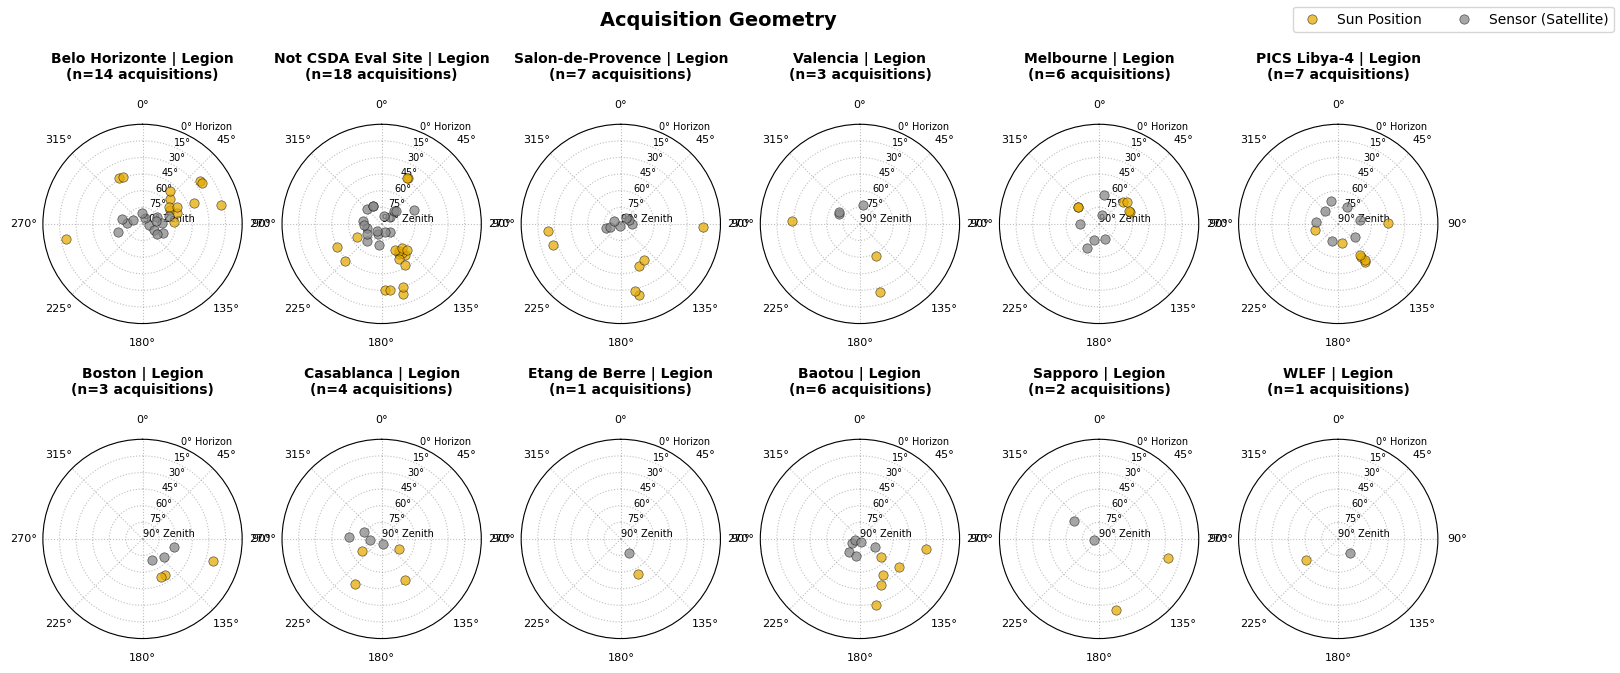

In [175]:
# Example breakdown on how to call your new function:
plot_skyplots_by_site_and_sensor(footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.constellation == 'Legion'], sensor_col='constellation', site_col='Site_Primary')

In [90]:
footprint_gdf_acquisitions_sites.head()

,affiliation,constellation,sensor,acquisition_id,path,image_type,acquisition_date,year,month,day,...,scene_id,sun_azimuth,sun_elevation,satellite_azimuth,satellite_elevation,Site_Primary,Site_Secondary,Site_Tertiary,num_sites,sites
0,Satellogic,Aleph-1,SN10,20210202_090141_SN10_L1D_MS_None,/explore/nobackup/projects/CSDA_eval/Data/Sate...,MS,2021-02-02,2021,2,2,...,None,149.203,38.905,97.715,24.643,PICS Libya-4,None,None,1,PICS Libya-4
1,Satellogic,Aleph-1,SN10,20210205_091047_SN10_L1D_MS_27152,/explore/nobackup/projects/CSDA_eval/Data/Sate...,MS,2021-02-05,2021,2,5,...,None,151.127,40.641,273.296,2.298,PICS Libya-4,None,None,1,PICS Libya-4
2,Satellogic,Aleph-1,SN10,20210212_090048_SN10_L1D_MS_27152,/explore/nobackup/projects/CSDA_eval/Data/Sate...,MS,2021-02-12,2021,2,12,...,None,146.751,41.552,97.494,26.537,PICS Libya-4,None,None,1,PICS Libya-4
3,Satellogic,Aleph-1,SN10,20210215_090944_SN10_L1D_MS_None,/explore/nobackup/projects/CSDA_eval/Data/Sate...,MS,2021-02-15,2021,2,15,...,None,148.802,43.407,156.953,0.187,PICS Libya-4,None,None,1,PICS Libya-4
4,Satellogic,Aleph-1,SN16,20210303_111934_SN16_L1D_MS_28280,/explore/nobackup/projects/CSDA_eval/Data/Sate...,MS,2021-03-03,2021,3,3,...,None,150.163,45.264,277.540,7.002,Casablanca,None,None,1,Casablanca


In [33]:
#footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.sensor == 'Tanager-1'].explore()

In [34]:
print(footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.image_type == 'MS, P'].head(1).scene_path_list.to_list())


['/explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_PAN/25JUN08220602-P2AS_R1C2-200008787224_01_P001.TIF, /explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_MUL/25JUN08220602-M2AS_R3C1-200008787224_01_P001.TIF, /explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_PAN/25JUN08220602-P2AS_R2C2-200008787224_01_P001.TIF, /explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_MUL/25JUN08220602-M2AS_R1C2-200008787224_01_P001.TIF, /explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_MUL/25JUN08220602-M2AS_R2C1-200008787224_01_P001.TIF, /explore/nobackup/projects/CSDA_eval/Data/Maxar/Legion/delivery/B120001101D41700/200008787224_01/200008787224_01_P001_PAN/25JUN08220602-P2

In [35]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [36]:
m = csdalib.make_CSDA_footprints_map(footprint_gdf_acquisitions_sites#[footprint_gdf_acquisitions_sites.image_type != 'PAN']#.drop('acquisition_datetime', axis=1).to_crs(4326)
                                 #, height='25%'
                                 , ACQS=True, site_name_col='sites'
                                 , MAP = sites_gdf.explore(style_kwds=dict(style_function=csdalib.dashed_style), name='Sites (actual)', 
                                                           m=sites_gdf_buf_display.explore(style_kwds=dict(style_function=csdalib.dashed_style), name='Sites (display)')),
                                 TOOLTIP_FIELDS_LIST = ['affiliation','constellation','sensor','acquisition_id','image_type','acquisition_date']
                                )

QML file created: footprints_CSDA_eval_ACQUISITIONS_combined_label_color_dict.qml


In [174]:
m

### Make HTML for webmap of footprints

In [37]:
out_html = '/home/pmontesa/code/csda_summaries/notebooks/footprints_csda_map.html'

In [38]:
# Save to html

In [39]:
import os

# 1. Save the map as usual
m.save(out_html)

# 2. Build the header HTML (title + image + description)
header_html = """
    <!-- Outer card container -->
    <div style='padding: 28px 36px; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif; max-width: 1100px; margin: 24px auto; color: #222; background: #91bfdb; border: 1px solid #e0e6ee; border-radius: 10px; box-shadow: 0 2px 6px rgba(31, 77, 140, 0.06);'>
      
      <!-- Eyebrow tag -->
      <div style='display: inline-block; background: #fee090; color: #1f4d8c; padding: 4px 10px; border-radius: 4px; font-size: 0.78em; font-weight: 600; letter-spacing: 0.04em; text-transform: uppercase; margin-bottom: 10px;'>
        CSDA Evaluation Image Footprints
      </div>
      
      <!-- Title -->
      <h1 style='color: #1f4d8c; font-size: 1.85em; line-height: 1.25; margin: 0 0 6px 0; font-weight: 600;'>
        Interactive map of footprints of images available for CSDA SME Evaluations
      </h1>
      
      <!-- Subtitle/lede -->
      <p style='font-size: 1em; line-height: 1.55; margin: 6px 0 18px 0; color: #4a5568;'>
        These are imagery delivered in response to CSDA requests at sites from the <a href='https://docs.google.com/spreadsheets/d/13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k/edit?gid=538266839#gid=538266839' target='_blank' style='color: #1f4d8c; text-decoration: none; border-bottom: 2px solid #cfdcef;'>CSDA Evaluation Sites Database</a>.
      </p>
      
      <!-- Key features list -->
      <div style='background: #f6f9fd; border-left: 3px solid #1f4d8c; padding: 12px 16px; margin: 16px 0; border-radius: 0 4px 4px 0;'>
        <p style='margin: 0 0 8px 0; font-size: 0.95em; font-weight: 600; color: #1f4d8c;'>Each image footprint:</p>
        <ul style='margin: 0; padding-left: 20px; font-size: 0.95em; line-height: 1.55; color: #333;'>
          <li>is located at a CSDA Evaluation Site named using a unique identifier (<code style='background:#fff; padding:1px 5px; border-radius:3px; font-size:0.9em; border: 1px solid #e0e6ee;'>Site Name</code>)</li>
          <li>has geometric bounds representing the acauisition extent</li>
          <li>includes basic attributes associated with the image acquisition</li>
        </ul>
      </div>
      
      <!-- Display note -->
      <p style='font-size: 0.95em; line-height: 1.55; margin: 14px 0; color: #4a5568;'>
        Image footprint geometry should <b>completely cover</b> an site AOI. Mouse over footprints for acquisition details.
      </p>
      
      <!-- Footer row: status + contact -->
      <div style='display: flex; justify-content: space-between; align-items: center; margin-top: 18px; padding-top: 12px; border-top: 1px solid #e0e6ee; font-size: 0.85em; color: #718096;'>
        <span style='font-style: italic;'>Work in progress — some images were not properly footprinted and are missing from this map.</span>
        <span><b>Contact:</b> <a href='mailto:paul.m.montesano@nasa.gov' style='color: #1f4d8c; text-decoration: none;'>paul.m.montesano@nasa.gov</a></span>
      </div>
      
    </div>
"""


# 3. CSS to make the folium map fill the page width and a tall portion of the viewport
fullwidth_css = """
<style>
  body { margin: 0; padding: 0; }
  /* Folium map container — override fixed width/height */
  .folium-map {
    width: 100% !important;
    height: 45vh !important;
    max-width: 100% !important;
  }
  /* If folium wraps the map in a Figure div, also stretch it */
  div[id^="map_"] {
    width: 100% !important;
    height: 45vh !important;
  }
</style>
"""

# 4. Inject header + CSS right after <body>
with open(out_html, 'r') as f:
    html = f.read()

html = html.replace('<body>', f'<body>\n{fullwidth_css}\n{header_html}', 1)

with open(out_html, 'w') as f:
    f.write(html)

print(f"Saved {out_html} — push to GitHub to view at:")
print(f"  https://pahbs.github.io/maap_tools/maps/{out_html}")


Saved /home/pmontesa/code/csda_summaries/notebooks/footprints_csda_map.html — push to GitHub to view at:
  https://pahbs.github.io/maap_tools/maps//home/pmontesa/code/csda_summaries/notebooks/footprints_csda_map.html


## Plot maps of sites and their acqs (static)

In [40]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import contextily as ctx

import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter, MonthLocator, WeekdayLocator

### Explore XML to learn about fields in order to update `sensor_profiles.py`

In [46]:
# import xml.etree.ElementTree as ET

# # Pick a sample XML
# xml_path = '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF02_20260404_00501045_0000008716_L2A.xml'

# # These separate images have same Image_ID ... bad
# xml_path_list = [
#     '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF01_20251104_00501045_0000002446_L2A.xml',
#     '/explore/nobackup/projects/CSDA_eval/Data/Pixxel/V3/FF02_20251025_00501045_0000002446_L2A.xml'
# ]
# for xml_path in xml_path_list:
#     tree = ET.parse(xml_path)
#     root = tree.getroot()
    
#     # Strip namespaces
#     for elem in root.iter():
#         if '}' in elem.tag:
#             elem.tag = elem.tag.split('}', 1)[1]
    
#     # Print all leaf elements (the actual data tags)
#     def walk(elem, path=''):
#         tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
#         cur = f'{path}/{tag}' if path else tag
#         if len(list(elem)) == 0:   # leaf node
#             text = (elem.text or '').strip()
#             if text:
#                 print(f'  {cur}: {text[:60]}')
#         for child in elem:
#             walk(child, cur)
    
#     walk(root)
#     print('\n')

In [47]:
footprint_gdf[footprint_gdf.acquisition_id == '0000002446'].metadata_path.to_list()

[]

### Strange case of SPOT images with same ID (Albuquerque & Shadnagar)

Now the picture is clear. This is a real data anomaly: two physically distinct SPOT6 acquisitions have the exact same filenames (IMG_SPOT6_MS_202601230453359_SEN_7674265101_R1C1.TIF):  

First 8 files: Shadnagar, India (17.0°N, 78.2°E) in /Airbus/SPOT/shadnagar/...  
Second 8 files: New Mexico (35.1°N, -106.6°W) in /Airbus/PROD_SPOT6_001/...  
Same timestamp (202601230453359), same CATID (7674265101), same product code. Either:  

Airbus genuinely delivered two different acquisitions with the same identifier (vendor metadata bug)  
The vendor reused a CATID for two physically different deliveries (also a vendor issue)  
You have a folder copied twice on disk (your data layout issue)  
Either way, the canonical metadata field (DATASET_NAME / JOB_ID, which gives SEN_SPOT6_20260123_045336100_000) is not actually unique across deliveries in your data. So acquisition_id alone can't disambiguate them.  

In [48]:
# Filter for records that contain a comma in the sites column
multiple_sites_gdf = footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites['sites'].str.contains(',', na=False)]
multiple_sites_gdf.head()

,affiliation,constellation,sensor,acquisition_id,path,image_type,acquisition_date,year,month,day,scene_path_list,geometry,scene_id,Site_Primary,Site_Secondary,Site_Tertiary,num_sites,sites,combined_label
14,Maxar,Legion,LG01,200009817627_01_P001,/explore/nobackup/projects/CSDA_eval/Data/Maxa...,"P, MS",2025-08-25,2025,8,25,/explore/nobackup/projects/CSDA_eval/Data/Maxa...,"POLYGON ((4.97110 43.35251, 4.97277 43.40389, ...","R16C3, R07C2, R13C1, R01C2, R16C2, R04C1, R11C...",Etang de Berre,Salon-de-Provence,None,2,"Etang de Berre, Salon-de-Provence",Maxar - Legion
159,Planet,Tanager,Tanager-1,20260602_100039_57_4001,/explore/nobackup/projects/CSDA_eval/Data/Plan...,HYPER,2026-06-02,2026,6,2,/explore/nobackup/projects/CSDA_eval/Data/Plan...,"POLYGON ((32.56918 38.00164, 32.66923 37.83782...",None,Konya-airport,Konya-city,None,2,"Konya-airport, Konya-city",Planet - Tanager
170,Airbus,Pleiades,PHR1A,DS_PHR1A_202508221045161_FR1_PX_E004N43_1114_0...,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"MS, P",2025-08-22,2025,8,22,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"POLYGON ((4.97863 43.46969, 4.93356 43.47046, ...","R1C1, R2C1, R2C2, R1C2",La Crau,La Crau TIR,None,2,"La Crau, La Crau TIR",Airbus - Pleiades
182,Airbus,Pleiades,PHR1A,DS_PHR1A_202509091823434_FR1_PX_W113N33_1013_0...,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"MS, P",2025-09-09,2025,9,9,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"POLYGON ((-112.14638 33.41441, -112.18558 33.4...","R1C1, R2C1, R2C2, R1C2",AZ Maricopa Pinal,Phoenix,None,2,"AZ Maricopa Pinal, Phoenix",Airbus - Pleiades
188,Airbus,Pleiades,PHR1A,DS_PHR1A_202510051823484_FR1_PX_W113N33_1012_0...,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"MS, P",2025-10-05,2025,10,5,/explore/nobackup/projects/CSDA_eval/Data/Airb...,"POLYGON ((-112.35748 33.40597, -112.35776 33.4...","R1C1, R2C1, R2C2, R1C2",AZ Maricopa Pinal,Phoenix,None,2,"AZ Maricopa Pinal, Phoenix",Airbus - Pleiades


In [63]:
# Define sites to plot
sites_to_plot = sorted([site for site in footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.constellation == 'Legion'].Site_Primary.unique() if site != 'Not CSDA Eval Site'])
print(sites_to_plot)

['Baotou', 'Belo Horizonte', 'Boston', 'Casablanca', 'Etang de Berre', 'Melbourne', 'PICS Libya-4', 'Salon-de-Provence', 'Sapporo', 'Valencia', 'WLEF']


In [50]:
 #footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.Site_Primary.isin(sites_to_plot)].explore()

In [51]:
# # Define sites to plot
# sites_to_plot = sorted([site for site in footprint_gdf_acquisitions_sites.Site_Primary.unique() if site == 'Boston'])
# len(sites_to_plot)

In [77]:
 footprint_gdf_acquisitions_sites[
                            (footprint_gdf_acquisitions_sites.constellation == 'Legion') & 
                            (footprint_gdf_acquisitions_sites.image_type.str.contains('MS', na=False))
                        ].shape

(78, 19)

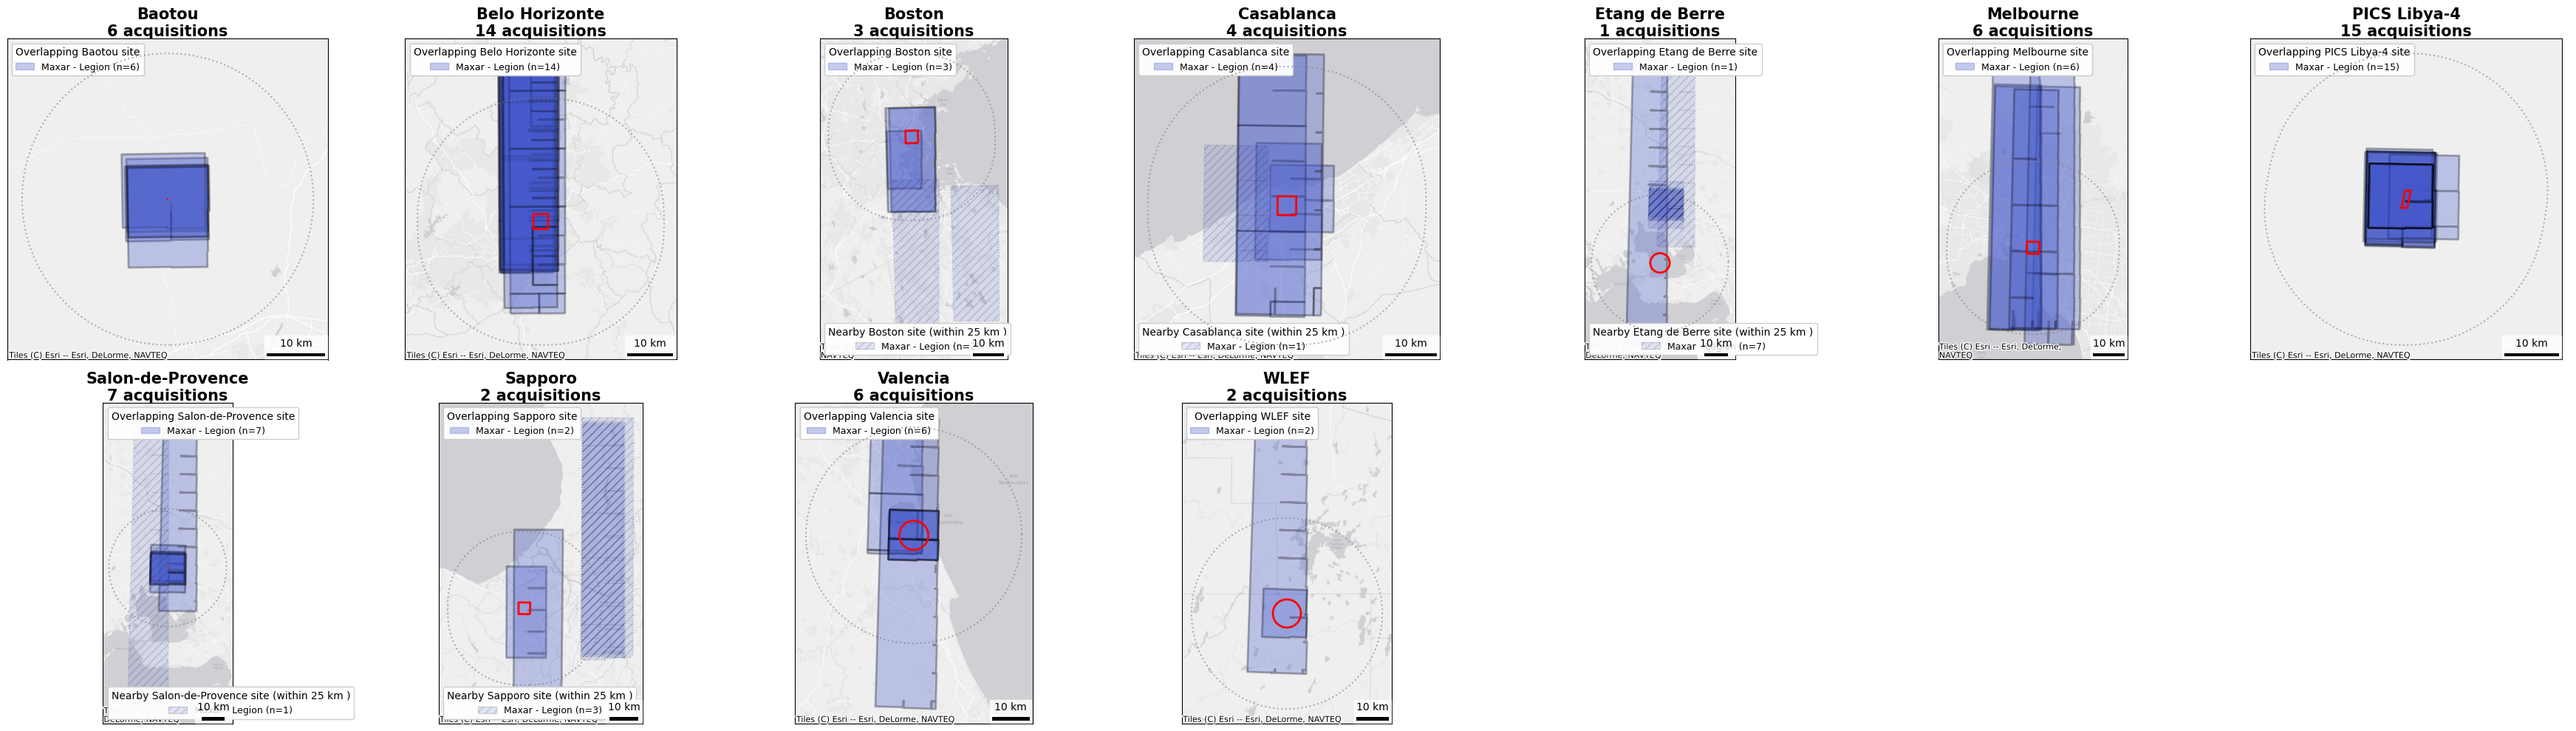

In [71]:
# Create grid
n_sites = len(sites_to_plot)
n_cols = 7
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot each site
for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(site_name, 
                      footprint_gdf_acquisitions_sites[
                            (footprint_gdf_acquisitions_sites.constellation == 'Legion') & 
                            (footprint_gdf_acquisitions_sites.image_type.str.contains('MS', na=False))
                        ], 
                      sites_gdf, 
                      #0, 
                       BUF_KM_TOTAL_FOR_DISPLAY,
                      sites_buf_gdf=sites_gdf_buf_display,
                      ax=axes[idx])  # Pass the axis here

# Hide unused subplots
for idx in range(n_sites, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Create Comprehensive Summary of Multispectral Acquisitions

#### merging Acquisitions with Requested Acquisitions

how='left' (Recommended for most cases)  

+ Keeps all rows from summary_by_site (actual data you have)
+ Adds requested_acqs information where it matches
+ Use this if: You want to see all the data you actually collected, with requested acquisition counts added where available  
Result: Shows what you have, annotated with what was requested  

how='outer' (What you're currently using)  

+ Keeps all rows from both dataframes
+ Use this if: You want to see both what you collected AND what was requested (even if you didn't collect it)  
Result: Can show gaps - sites/sensors you were supposed to collect but didn't  

how='right'  

+ Keeps all rows from requested_acqs
+ Use this if: You only care about the requested combinations and want to see which ones you fulfilled  
Result: Only shows requested combinations, with actual data where available  

how='inner'  

+ Only keeps rows that match in both dataframes
+ Use this if: You only want to see requested combinations that you actually collected  
Result: Excludes both unrequested data you collected AND requested data you didn't collect  

In [72]:
requested_acqs[requested_acqs.Site == 'Baotou']

,affiliation,constellation,sensor,Site,Acquisitions Requested,Product,Request Date,Acquisition Date,Science Team Received
71,Maxar,Legion,LG01,Baotou,6,NaN,NaN,NaN,NaN


In [73]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [74]:
footprint_gdf_acquisitions_sites.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 578 entries, 0 to 577
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   affiliation       578 non-null    object  
 1   constellation     578 non-null    object  
 2   sensor            578 non-null    object  
 3   acquisition_id    578 non-null    object  
 4   path              578 non-null    object  
 5   image_type        578 non-null    object  
 6   acquisition_date  578 non-null    object  
 7   year              578 non-null    int64   
 8   month             578 non-null    int64   
 9   day               578 non-null    int64   
 10  scene_path_list   578 non-null    object  
 11  geometry          578 non-null    geometry
 12  scene_id          578 non-null    object  
 13  Site_Primary      578 non-null    object  
 14  Site_Secondary    35 non-null     object  
 15  Site_Tertiary     10 non-null     object  
 16  num_sites         

In [75]:
# Filter out panchromatic if needed
footprint_filtered_multispec = footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.image_type != 'P']

# Step 2: Create comprehensive summaries
summaries = csdalib.create_comprehensive_summary(
    footprint_filtered_multispec,
    acq_site_mapping,
    site_name_col='Site_Primary',
    exclude_sites='Not CSDA Eval Site'
)

# Access different summaries:
site_summary            = summaries['by_site']  # Primary site assignments (no double counting)
sensor_summary          = summaries['by_sensor']  # Total by sensor
affiliation_summary     = summaries['by_affiliation']  # Total by affiliation
constellation_summary   = summaries['by_constellation']  # Total by constellation
multi_site              = summaries['multi_site_acquisitions']  # Acquisitions covering multiple sites
all_site_associations   = summaries['by_site_all_associations']  # All site-acquisition relationships

# Step 3: Merge with requested acquisitions
final_summary = pd.merge(
    #site_summary,
    site_summary.groupby(['Site_Primary','affiliation','constellation','sensor']).agg(sum).reset_index(),
    requested_acqs,
    left_on=['Site_Primary', 'affiliation', 'constellation', 'sensor'],
    right_on=['Site', 'affiliation', 'constellation', 'sensor'],
    how='outer'
)#.drop(columns=[
##    #'Site', 
#    'Affiliation', 'Constellation/Platform', 'Sensor/Generation'])

final_summary['acquisition_count'] = final_summary['acquisition_count'].fillna(0).astype(int)

final_summary['Acquisitions Requested'] = final_summary['Acquisitions Requested'].fillna(0).astype(int)
final_summary['Acquisitions Remaining'] = final_summary['Acquisitions Requested'] - final_summary['acquisition_count']
final_summary.loc[final_summary['Acquisitions Remaining'] < 0, 'Acquisitions Remaining'] = 0
out_csv_fn = f'/explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_summary_MS_{today_date_string}.csv'
print(f"Saving: {out_csv_fn}")
final_summary.to_csv(out_csv_fn)


Summary of acquisitions at CSDA Evaluation Sites
(excluding sites: Not CSDA Eval Site)
Total Affiliations:             5
Total Constellations:           7
Total Evaluation Sites:        31
Total Images:                 455
----------------------------------------------------------------------

Breakdown by Affiliation:
  Airbus                  209 images
  Pixxel                  106 images
  Maxar                    66 images
  Satellogic               55 images
  Planet                   19 images

Breakdown by Constellation:
  Pixxel/Firefly                           106 images
  Airbus/Pleiades Neo                       96 images
  Airbus/Pleiades                           78 images
  Maxar/Legion                             66 images
  Satellogic/Aleph-1                            55 images
  Airbus/SPOT                               35 images
  Planet/Tanager                            19 images

Saving: /explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_s

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_679463/2148503429.py:23: FutureWarning: The operation <built-in function sum> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  site_summary.groupby(['Site_Primary','affiliation','constellation','sensor']).agg(sum).reset_index(),


## Create `latest` footprint `gpkg` and summary `csv` files

In [76]:
import os
import glob

# Usage example:
dir_list = ['/explore/nobackup/projects/CSDA_eval/summaries',
            '/explore/nobackup/projects/CSDA_eval/footprints'
           ]

for directory in dir_list:
    # Delete existing *_latest.csv and *_latest.gpkg files
    for ext in ['csv', 'gpkg']:
        latest_pattern = os.path.join(directory, f'*_latest.{ext}')
        existing_latest = glob.glob(latest_pattern)
        for file in existing_latest:
            try:
                os.remove(file)
                print(f"Deleted existing file: {os.path.basename(file)}")
            except Exception as e:
                print(f"Warning: Could not delete {file}: {e}")
    
    # Now copy the latest files
    latest_files = csdalib.copy_all_latest_files(directory, extensions=['csv', 'gpkg'])

    cmd = f'chmod -R 755 {directory}'
    print(f'\n\tOpening up access with chmod: {cmd}')
    !eval $cmd
    
    # Show results
    print("\n=== Summary ===")
    for key, filepath in latest_files.items():
        print(f"{key}: {os.path.basename(filepath)}")

Deleted existing file: CSDA_eval_sites_footprint_summarypivot_MS_latest.csv
Deleted existing file: CSDA_eval_sites_footprint_summary_MS_latest.csv
Deleted existing file: CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv
Found 47 dated files

=== Processing files ===
  Copied: CSDA_eval_sites_footprint_summary_MS_2026-08-13.csv -> CSDA_eval_sites_footprint_summary_MS_latest.csv (date: 2026-08-13)
  Copied: CSDA_eval_sites_footprint_summary_MS_sorted_2026-06-05.csv -> CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv (date: 2026-06-05)
  Copied: CSDA_eval_sites_footprint_summarypivot_MS_2026-02-12.csv -> CSDA_eval_sites_footprint_summarypivot_MS_latest.csv (date: 2026-02-12)

	Opening up access with chmod: chmod -R 755 /explore/nobackup/projects/CSDA_eval/summaries

=== Summary ===
CSDA_eval_sites_footprint_summary_MS.csv: CSDA_eval_sites_footprint_summary_MS_latest.csv
CSDA_eval_sites_footprint_summary_MS_sorted.csv: CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv
CSDA_